# CatBoost Baseline (Optimal Features) - PS-S06E08

This notebook implements a CatBoost baseline for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, multi-seed training, and hyperparameter tuning with an SQLite-backed Optuna database.

**Key diagnostic**: Based on feature engineering CV tests, CatBoost's symmetric trees benefit from explicit interaction terms. We use the full set of 69 engineered features (including numeric expansions) and have eliminated the RFE step.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,  # Set to True on GPU-enabled environments
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding'
]

print('Performing feature engineering (all engineered features)...')
factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f'Train features shape: {X.shape}')
print(f'Test features shape: {X_test.shape}')

Performing feature engineering (all engineered features)...
  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding
  -> Imputing missing values using learned medians and modes...
  -> Encoding categorical variables...
Applying FeatureFactory with strategies: encoding
  -> Imputing missing values using learned medians and modes...
  -> Encoding categorical variables...
Train features shape: (691369, 12)
Test features shape: (296302, 12)


## 4. SQLite-Backed Optuna Optimization

Tunes model hyperparameters over a 5-fold CV split, caching trials dynamically in an SQLite database.

In [5]:
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
for tr_idx, val_idx in skf_cv.split(X, y):
    fold_cache.append((tr_idx, val_idx))

def objective(trial):
    params = {
        'iterations': 1000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'random_seed': seed,
        'allow_writing_files': False,
        'verbose': False,
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0)
    }
    
    oof_preds = np.full(len(y), -1.0, dtype=float)
    
    for fold, (tr_idx, val_idx) in enumerate(fold_cache):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        cat_cols = X_tr.select_dtypes(include=['category', 'object']).columns.tolist()
        X_tr_str = X_tr.copy()
        X_val_str = X_val.copy()
        for col in cat_cols:
            X_tr_str[col] = X_tr_str[col].astype(str)
            X_val_str[col] = X_val_str[col].astype(str)
            
        train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols)
        val_pool = Pool(X_val_str, y_val, cat_features=cat_cols)
        
        model = cb.CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=50,
            verbose=False
        )
        
        preds = model.predict_proba(val_pool)[:, 1]
        oof_preds[val_idx] = preds
        fold_score = roc_auc_score(y_val, preds)
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    filled_mask = oof_preds >= 0
    return roc_auc_score(y[filled_mask], oof_preds[filled_mask])

In [6]:
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print("Starting CatBoost SQLite Optuna Optimization (all engineered features)...")
    
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1
    )
    
    study = optuna.create_study(
        storage='sqlite:///catboost_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='cb_raw_features_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    study.optimize(objective, n_trials=100, timeout=7200, show_progress_bar=True)
    best_params = study.best_params
    print("Best params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print("Using loaded parameters:", best_params)

Loaded 5 parameters from optuna_params_catboost.json
Using loaded parameters: {'depth': 5, 'learning_rate': 0.2801611607358835, 'l2_leaf_reg': 2.81541299597934, 'random_strength': 0.0022062714104688326, 'bagging_temperature': 0.0612050689136209}


## 5. Model Training & Multi-Seed Blending

Trains the final seed-averaged models on the optimal engineered features.

In [7]:
seeds = setup.seed()

# Track multi-class style probabilities: column 0 = prob(0), column 1 = prob(1)
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"\n================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")
    
    cb_params = {
        **best_params,
        'iterations': 4000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'random_seed': current_seed,
        'allow_writing_files': False,
        'verbose': False
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        cat_cols = X_tr.select_dtypes(include=['category', 'object']).columns.tolist()
        X_tr_str = X_tr.copy()
        X_val_str = X_val.copy()
        X_test_str = X_test.copy()
        
        for col in cat_cols:
            X_tr_str[col] = X_tr_str[col].astype(str)
            X_val_str[col] = X_val_str[col].astype(str)
            X_test_str[col] = X_test_str[col].astype(str)
            
        train_pool = Pool(X_tr_str, y_tr, cat_features=cat_cols)
        val_pool = Pool(X_val_str, y_val, cat_features=cat_cols)
        test_pool = Pool(X_test_str, cat_features=cat_cols)
        
        model = cb.CatBoostClassifier(**cb_params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=100,
            verbose=False
        )
        
        # Predict probabilities
        val_probs = model.predict_proba(val_pool)
        oof_probs_seed[val_idx] = val_probs
        filled_mask[val_idx] = True
        
        test_probs_seed += model.predict_proba(test_pool) / 5.0
        
        fold_score = roc_auc_score(y_val, val_probs[:, 1])
        n_trees = model.tree_count_
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")
        
        models.append(model)
        eval_results.append(model.get_evals_result())
        
    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")
    
    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)
    
overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 ROC AUC: 0.958750 (trees=898)


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 ROC AUC: 0.959456 (trees=1230)


...

  Fold 3 ROC AUC: 0.960261 (trees=1084)


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 ROC AUC: 0.959700 (trees=827)


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 ROC AUC: 0.959415 (trees=1085)
--- Seed 888 CV ROC AUC: 0.959625 ---

Seed-Averaged CV ROC AUC: 0.960629


## 6. Performance Visualization

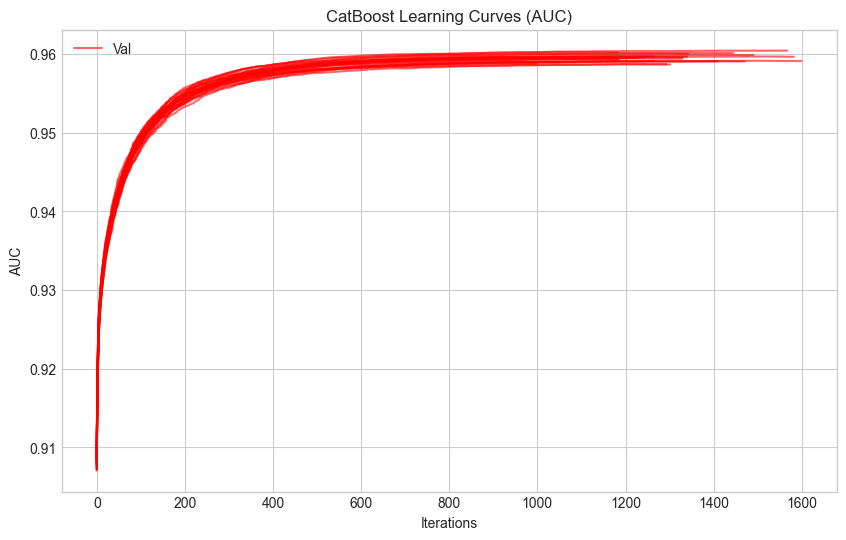

In [8]:
mviz = ModelVisualizer(model_name='CatBoost')

# Map learning metrics to ModelVisualizer expectations
adjusted_evals = []
for res in eval_results:
    adjusted_evals.append({
        'validation_0': res['validation'],
        'validation_1': res['learn']
    })

mviz.plot_learning_curves(adjusted_evals, metric='AUC')

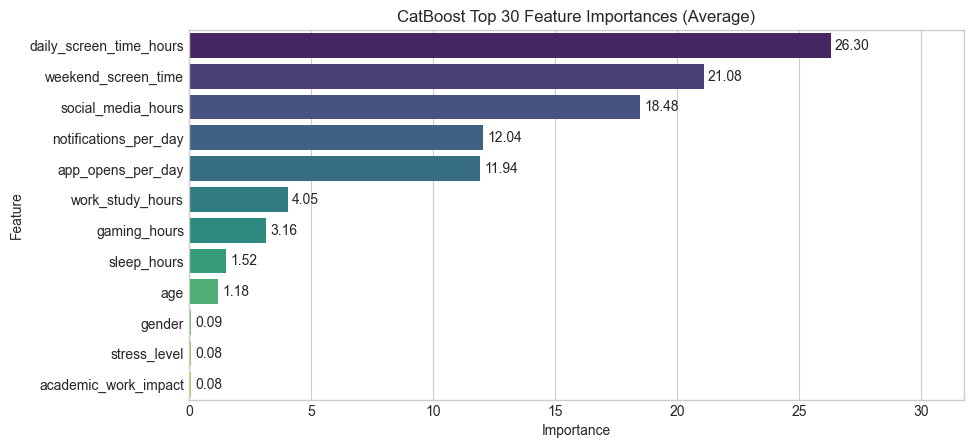

In [9]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

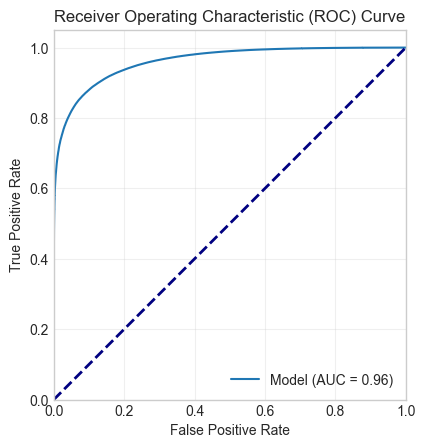

In [10]:
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


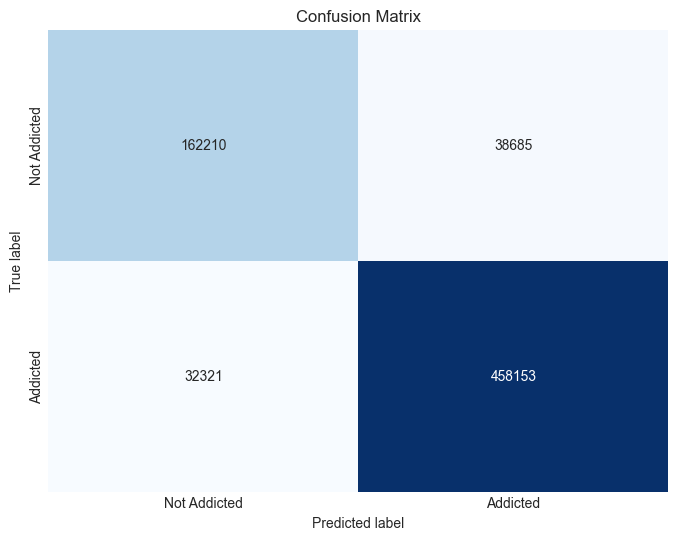

In [11]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 7. Export Submission & Predictions

In [12]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [13]:
setup.save_probabilities('cb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/cb_oof_probs.csv
 - predictions/cb_test_probs.csv
